# ANN Practical Project: Loan Approval Prediction

## Problem Type: Binary Classification

Is project mein hum Artificial Neural Network (ANN) use karenge taake predict kar saken:

- **1 = Loan Approved**
- **0 = Loan Rejected**

Ye dataset tabular data par based hai, is liye ANN ke liye perfect practical hai.

## Step 1: Required Libraries Import Karein

Yahan hum data handling, visualization, preprocessing, model building aur evaluation ke liye libraries import kar rahe hain.

In [1]:
# Data ko read aur manage karne ke liye pandas use hota hai
import pandas as pd
# Numerical calculations ke liye numpy use hota hai
import numpy as np

# Graphs banane ke liye matplotlib use hota hai
import matplotlib.pyplot as plt

# Train-test split ke liye
from sklearn.model_selection import train_test_split

# Numerical features ko scale karne ke liye
from sklearn.preprocessing import StandardScaler

# Model performance check karne ke liye metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# TensorFlow/Keras se ANN model banayenge
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

print('TensorFlow Version:', tf.__version__)

TensorFlow Version: 2.21.0


## Step 2: Dataset Load Karein

`ANN_Loan_Approval_Dataset.csv` ko same folder mein rakhein jahan ye notebook hai.

In [3]:
# CSV file read kar rahe hain
df = pd.read_csv('ANN_Loan_Approval_Dataset.csv')

# Pehli 5 rows show kar rahe hain
df.head()

,Application_ID,Age,Education,Employment_Type,Marital_Status,Dependents,Property_Area,Experience_Years,Monthly_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Existing_Loan,EMI,Savings,Debt_to_Income_Ratio,Loan_Approved
0,APP-00001,59,Bachelor,Salaried,Single,2,Urban,34,221390,650,1236074,72,Yes,21812,185203,0.099,1
1,APP-00002,42,Master,Self-employed,Married,2,Urban,16,162165,688,627035,12,Yes,60644,75725,0.374,0
2,APP-00003,64,Bachelor,Salaried,Single,3,Semiurban,36,138607,598,168148,60,No,3169,916606,0.023,1
3,APP-00004,27,Bachelor,Salaried,Married,3,Semiurban,2,169318,730,1608349,24,No,80043,1399673,0.473,1
4,APP-00005,49,Bachelor,Salaried,Married,4,Urban,21,125980,713,1502107,12,No,136435,589879,1.083,1


## Step 3: Dataset Basic Information

Is step mein hum columns, data types aur missing values check karenge.

In [4]:
# Dataset ka shape: rows aur columns
print('Dataset Shape:', df.shape)

# Columns ke data types aur non-null count
df.info()

Dataset Shape: (5000, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Application_ID        5000 non-null   object 
 1   Age                   5000 non-null   int64  
 2   Education             5000 non-null   object 
 3   Employment_Type       5000 non-null   object 
 4   Marital_Status        5000 non-null   object 
 5   Dependents            5000 non-null   int64  
 6   Property_Area         5000 non-null   object 
 7   Experience_Years      5000 non-null   int64  
 8   Monthly_Income        5000 non-null   int64  
 9   Credit_Score          5000 non-null   int64  
 10  Loan_Amount           5000 non-null   int64  
 11  Loan_Term_Months      5000 non-null   int64  
 12  Existing_Loan         5000 non-null   object 
 13  EMI                   5000 non-null   int64  
 14  Savings               5000 non-null   int64  


In [5]:
# Missing values check kar rahe hain
df.isnull().sum()

Application_ID          0
Age                     0
Education               0
Employment_Type         0
Marital_Status          0
Dependents              0
Property_Area           0
Experience_Years        0
Monthly_Income          0
Credit_Score            0
Loan_Amount             0
Loan_Term_Months        0
Existing_Loan           0
EMI                     0
Savings                 0
Debt_to_Income_Ratio    0
Loan_Approved           0
dtype: int64

## Step 4: Target Column Distribution

Yahan hum check karenge kitne loans approved aur rejected hain.

In [6]:
# Target column ka count
df['Loan_Approved'].value_counts()

Loan_Approved
1    3417
0    1583
Name: count, dtype: int64

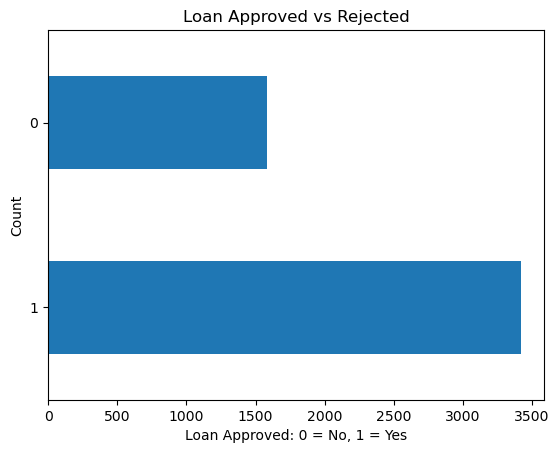

In [7]:
# Target distribution graph
df['Loan_Approved'].value_counts().plot(kind='barh')
plt.title('Loan Approved vs Rejected')
plt.xlabel('Loan Approved: 0 = No, 1 = Yes')
plt.ylabel('Count')
plt.show()

## Step 5: Features aur Target Separate Karein

- **X** = input features
- **y** = target/output

In [9]:
# Application_ID useful feature nahi hai, is liye drop kar rahe hain
# Loan_Approved target column hai, isay X se remove karna zaroori hai
X = df.drop(['Application_ID', 'Loan_Approved'], axis=1)

# Target variable
y = df['Loan_Approved']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (5000, 15)
y shape: (5000,)


## Step 6: Categorical Data Encoding

Deep Learning model text ko directly understand nahi karta. Is liye categorical columns ko numbers mein convert karna zaroori hota hai.

In [10]:
# get_dummies categorical columns ko numerical dummy columns mein convert karta hai
# drop_first=True se duplicate information kam hoti hai
X = pd.get_dummies(X, drop_first=True)

# Encoding ke baad features dekhte hain
X.head()

,Age,Dependents,Experience_Years,Monthly_Income,Credit_Score,Loan_Amount,Loan_Term_Months,EMI,Savings,Debt_to_Income_Ratio,...,Education_Master,Education_Matric,Education_PhD,Employment_Type_Salaried,Employment_Type_Self-employed,Employment_Type_Unemployed,Marital_Status_Single,Property_Area_Semiurban,Property_Area_Urban,Existing_Loan_Yes
0,59,2,34,221390,650,1236074,72,21812,185203,0.099,...,False,False,False,True,False,False,True,False,True,True
1,42,2,16,162165,688,627035,12,60644,75725,0.374,...,True,False,False,False,True,False,False,False,True,True
2,64,3,36,138607,598,168148,60,3169,916606,0.023,...,False,False,False,True,False,False,True,True,False,False
3,27,3,2,169318,730,1608349,24,80043,1399673,0.473,...,False,False,False,True,False,False,False,True,False,False
4,49,4,21,125980,713,1502107,12,136435,589879,1.083,...,False,False,False,True,False,False,False,False,True,False


## Step 7: Train Test Split

Data ko training aur testing mein divide karte hain.

- Training data model ko learn karne ke liye
- Testing data final performance check karne ke liye

In [11]:
# test_size=0.2 ka matlab 20% data testing ke liye hoga
# stratify=y target class balance maintain karta hai
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training Data:', X_train.shape)
print('Testing Data:', X_test.shape)

Training Data: (4000, 21)
Testing Data: (1000, 21)


## Step 8: Feature Scaling

ANN ke liye scaling bohat important hoti hai. Agar features different scales par hon, model slow ya poor learn karta hai.

In [12]:
# StandardScaler features ko mean=0 aur std=1 ke around scale karta hai
scaler = StandardScaler()

# Training data par fit_transform
X_train_scaled = scaler.fit_transform(X_train)

# Test data par sirf transform, fit nahi karte taake data leakage na ho
X_test_scaled = scaler.transform(X_test)

In [13]:
X_train_scaled

array([[-1.45322667e+00, -1.42204914e+00, -1.39695722e+00, ...,
         1.32972407e+00, -8.99974861e-01, -7.65945139e-01],
       [-1.05565422e+00,  1.42062780e+00, -9.88967379e-01, ...,
        -7.52035724e-01,  1.11114215e+00,  1.30557653e+00],
       [-1.29419769e+00, -7.10669234e-04, -1.39695722e+00, ...,
        -7.52035724e-01, -8.99974861e-01, -7.65945139e-01],
       ...,
       [ 1.17075145e+00,  1.42062780e+00,  9.69383866e-01, ...,
        -7.52035724e-01,  1.11114215e+00, -7.65945139e-01],
       [ 1.48880940e+00, -7.10669234e-04,  1.70376558e+00, ...,
         1.32972407e+00, -8.99974861e-01, -7.65945139e-01],
       [-1.01480366e-01, -7.11379903e-01, -3.36183630e-01, ...,
        -7.52035724e-01,  1.11114215e+00, -7.65945139e-01]],
      shape=(4000, 21))

In [14]:
X_test_scaled

array([[ 4.55121052e-01, -7.10669234e-04,  7.24589961e-01, ...,
        -7.52035724e-01, -8.99974861e-01, -7.65945139e-01],
       [ 1.72735286e+00, -7.11379903e-01,  1.45897168e+00, ...,
        -7.52035724e-01, -8.99974861e-01, -7.65945139e-01],
       [ 2.96092076e-01,  1.42062780e+00,  3.98198087e-01, ...,
        -7.52035724e-01, -8.99974861e-01, -7.65945139e-01],
       ...,
       [-1.01480366e-01, -1.42204914e+00, -2.54585662e-01, ...,
        -7.52035724e-01, -8.99974861e-01,  1.30557653e+00],
       [ 5.34635540e-01, -7.10669234e-04,  3.98198087e-01, ...,
        -7.52035724e-01, -8.99974861e-01, -7.65945139e-01],
       [ 3.75606564e-01,  7.09958565e-01,  7.18062123e-02, ...,
        -7.52035724e-01, -8.99974861e-01, -7.65945139e-01]],
      shape=(1000, 21))

## Step 9: ANN Model Build Karein

Yahan hum Artificial Neural Network build karenge.

- Input layer automatically first Dense layer se handle hoti hai.
- Hidden layers ReLU activation use karti hain.
- Output layer sigmoid use karti hai kyun ke ye binary classification hai.

In [15]:
X_train_scaled.shape

(4000, 21)

In [16]:
X_train_scaled.shape[1]

21

In [17]:
# Sequential ka matlab layers one-by-one add hongi
model = Sequential([
    # First hidden layer: 64 neurons, ReLU activation
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    
    # Dropout overfitting reduce karta hai
    Dropout(0.3),
    
    # Second hidden layer
    Dense(32, activation='relu'),
    
    # Third hidden layer
    Dense(16, activation='relu'),
    
    # Output layer: 1 neuron + sigmoid for binary output 0/1
    Dense(1, activation='sigmoid')
])

# Model summary architecture show karta hai
model.summary()

D:\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,033 (15.75 KB)

 Trainable params: 4,033 (15.75 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
import warnings
warnings.filterwarnings('ignore')

## Step 10: Model Compile Karein

- **optimizer='adam'**: weights update karta hai
- **loss='binary_crossentropy'**: binary classification ke liye best
- **metrics=['accuracy']**: accuracy track karega

In [ ]:
# Compile step training se pehle required hota hai
# model.compile(
#     optimizer='adam',
#     loss='binary_crossentropy',
#     metrics=['accuracy']
# )

In [19]:
# Model ko compile karna training se pehle zaroori hota hai.
# Is step mein hum optimizer, loss function aur evaluation metric define karte hain.

model.compile(

    # Optimizer model ke weights ko update karta hai taake loss kam ho.
    # Adam Deep Learning ka sab se popular aur efficient optimizer hai.
    optimizer='adam',

    # Binary Crossentropy binary classification ke liye use hota hai.
    # Hamare paas sirf 2 classes hain:
    # 0 = Loan Rejected
    # 1 = Loan Approved
    loss='binary_crossentropy',

    # Accuracy model ki performance ko measure karti hai.
    # Ye batati hai ke model ne kitni predictions sahi ki hain.
    metrics=['accuracy']
)

## Step 11: Model Train Karein

- **epochs**: model complete data kitni baar dekhega
- **batch_size**: ek time par kitne records process honge
- **validation_split**: training data ka kuch part validation ke liye use hoga

In [20]:
# Model training start
# Model ko training data par train kar rahe hain
history = model.fit(

    # Input features (scaled training data)
    X_train_scaled,

    # Target labels (Loan Approved / Rejected)
    y_train,

    # Model complete training data ko 30 baar dekhega
    epochs=30,

    # Ek time par 32 records process karega
    batch_size=32,

    # Training data ka 20% validation ke liye use hoga
    # Validation data model ki performance training ke duran check karta hai
    validation_split=0.2,

    # verbose=1 training progress (Epochs, Accuracy, Loss) screen par show karega
    # verbose=0 → Kuch bhi show nahi hoga
    # verbose=1 → Progress bar show hogi
    # verbose=2 → Sirf epoch-wise results show honge
    verbose=1
)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7497 - loss: 0.5058 - val_accuracy: 0.8462 - val_loss: 0.3656
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8541 - loss: 0.3375 - val_accuracy: 0.8650 - val_loss: 0.3093
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8600 - loss: 0.3129 - val_accuracy: 0.8800 - val_loss: 0.2896
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8703 - loss: 0.2951 - val_accuracy: 0.8763 - val_loss: 0.2864
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8800 - loss: 0.2768 - val_accuracy: 0.8813 - val_loss: 0.2773
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8800 - loss: 0.2727 - val_accuracy: 0.8763 - val_loss: 0.2703
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8850 - loss: 0.2633 - val_accuracy: 0.8838 - val_loss: 0.2715
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8866 - loss: 0.2541 - val_accuracy: 0.

## ✅ Step 12: Accuracy aur Loss Curves

Graphs se hum check karte hain ke model overfit ya underfit to nahi ho raha.

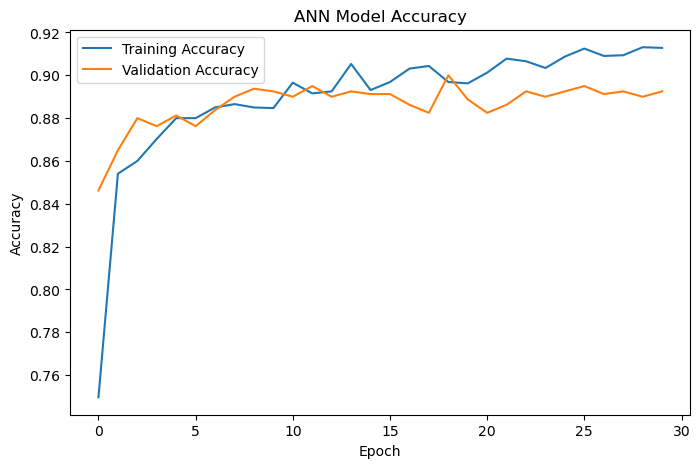

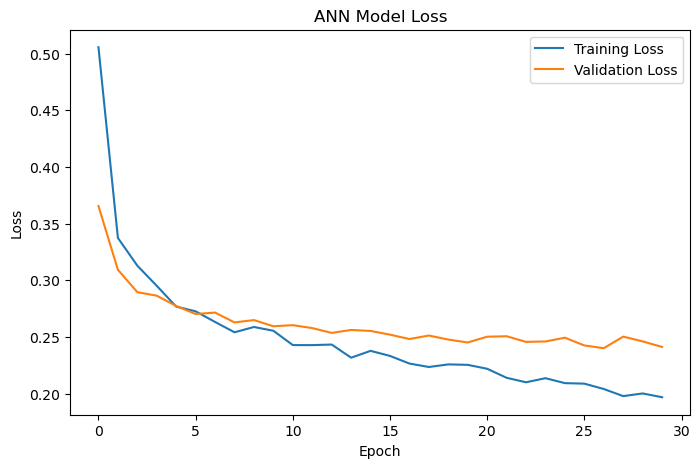

In [21]:
# Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('ANN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## ✅ Step 13: Model Evaluation

Test data par final result check karte hain.

In [22]:
# Test data par model evaluate
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)

print('Test Loss:', test_loss)
print('Test Accuracy:', test_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9010 - loss: 0.2315
Test Loss: 0.23148493468761444
Test Accuracy: 0.9010000228881836


## ✅ Step 14: Predictions + Classification Report

Model probability output deta hai. 0.5 threshold use karke probability ko class mein convert karte hain.

In [23]:
# Prediction probabilities
y_prob = model.predict(X_test_scaled)
y_prob

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


array([[9.99869466e-01],
       [9.97268796e-01],
       [9.87894356e-01],
       [9.99937177e-01],
       [8.17195654e-01],
       [7.84545720e-01],
       [3.17194045e-01],
       [1.20825861e-02],
       [9.99976039e-01],
       [9.40176547e-01],
       [9.99998629e-01],
       [9.97195303e-01],
       [9.70283687e-01],
       [9.99817967e-01],
       [5.74184179e-01],
       [9.99783814e-01],
       [7.15628858e-07],
       [1.62184164e-01],
       [7.40837455e-01],
       [2.11466555e-04],
       [9.99513030e-01],
       [9.37966466e-01],
       [9.99675989e-01],
       [2.28486329e-01],
       [9.78299916e-01],
       [1.87496673e-02],
       [8.05815101e-01],
       [9.40204680e-01],
       [8.40064168e-01],
       [1.00000000e+00],
       [8.56626272e-01],
       [3.36794853e-01],
       [9.98454511e-01],
       [9.93166029e-01],
       [6.35988474e-01],
       [9.93372351e-02],
       [8.81191250e-03],
       [2.40644142e-01],
       [9.99699652e-01],
       [9.47373867e-01],


In [24]:
# Probability > 0.5 ko 1 warna 0
y_pred = (y_prob > 0.5).astype(int).reshape(-1)
y_pred

array([1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,

In [26]:
# Accuracy score
print('Accuracy Score:', accuracy_score(y_test, y_pred))

# Confusion matrix
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

# Classification report
print('Classification Report:')
print(classification_report(y_test, y_pred))



Accuracy Score: 0.901
Confusion Matrix:
[[249  68]
 [ 31 652]]
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.79      0.83       317
           1       0.91      0.95      0.93       683

    accuracy                           0.90      1000
   macro avg       0.90      0.87      0.88      1000
weighted avg       0.90      0.90      0.90      1000



## ✅ Step 15: Single Customer Prediction

Ab hum ek new applicant ka loan approval predict karenge.

In [29]:
sample = X_test.iloc[[0]]

In [30]:
# Same scaler apply karna zaroori hai
sample_scaled = scaler.transform(sample)
sample_scaled

array([[ 4.55121052e-01, -7.10669234e-04,  7.24589961e-01,
         9.43507142e-01,  4.46154915e-01, -1.44133376e+00,
        -1.48479532e+00, -4.10522985e-01,  2.08065836e+00,
        -5.35799470e-01, -4.92566678e-01, -5.78504971e-01,
        -3.81842238e-01, -2.28205727e-01,  9.83633906e-01,
        -5.22952946e-01, -3.01840147e-01, -7.76663642e-01,
        -7.52035724e-01, -8.99974861e-01, -7.65945139e-01]])

In [31]:
(sample_scaled)[0][0]

np.float64(0.4551210519448946)

In [32]:
# Prediction probability
probability = model.predict(sample_scaled)[0][0]
probability

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


np.float32(0.99986947)

In [34]:
# Test set se ek applicant select kar rahe hain
sample = X_test.iloc[[0]]

# Same scaler apply karna zaroori hai
sample_scaled = scaler.transform(sample)

# Prediction probability
probability = model.predict(sample_scaled)[0][0]

# Final class decision
prediction = 1 if probability > 0.5 else 0

print('Loan Approval Probability:', probability)
print('Prediction:', 'Approved' if prediction == 1 else 'Rejected')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
Loan Approval Probability: 0.99986947
Prediction: Approved


In [35]:
# Test set se ek applicant select kar rahe hain
sample = X_test.iloc[[0]]

# Same scaler apply karna zaroori hai
sample_scaled = scaler.transform(sample)


# Prediction probability
probability = model.predict(sample_scaled)[0][0]

# Final class decision
if probability > 0.5:
    prediction = 1
else:
    prediction = 0

print("Loan Approval Probability:", probability)

# Prediction ko text mein convert karna
if prediction == 1:
    print("Prediction: Approved")
else:
    print("Prediction: Rejected")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Loan Approval Probability: 0.99986947
Prediction: Approved


# Practice Tasks

1. Epochs 30 se 50 karein aur result compare karein.
2. Dropout 0.3 se 0.5 karein.
3. Hidden layers ki neurons 64,32,16 se change karein.
4. Adam ki jagah SGD optimizer try karein.
5. Explain karein: Sigmoid output layer kyun use hui?
6. Explain karein: Binary Crossentropy loss kyun use hua?